# Librerias

In [1]:
import os
import joblib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn
import mlflow.xgboost

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
    xgboost_disponible = True
except Exception:
    xgboost_disponible = False
    print("XGBoost no está instalado. Si lo necesitas, instala: pip install xgboost")

In [2]:
# Configuración MLflow
mlflow.set_tracking_uri("http://44.200.196.170:5000/")
mlflow.set_experiment(f"Forecasting_SKU_{294000}")

<Experiment: artifact_location='mlflow-artifacts:/465688225033163177', creation_time=1783736660724, effective_trace_archival_retention=None, experiment_id='465688225033163177', last_update_time=1783736660724, lifecycle_stage='active', name='Forecasting_SKU_294000', tags={}, trace_location=None, workspace='default'>

In [3]:
# SKU
SKU = "294000"
NOMBRE_SKU = "Storage Box 27gal Professional"

# Rutas
ventas_path = "../DATA/raw/ventashistoricas_294000.csv"
pos_path = "../DATA/raw/POs_2974000.csv"
inventario_path = "../DATA/raw/Inventario actual.csv"

# Carpetas de salida
os.makedirs("../DATA/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# Revisar archivos disponibles

In [4]:
for root, dirs, files in os.walk("../DATA"):
    for file in files:
        print(os.path.join(root, file))

../DATA\processed\inventario_limpio.csv
../DATA\processed\inventario_resumen_skus.csv
../DATA\raw\Inventario actual.csv
../DATA\raw\Inventario actual.csv.dvc
../DATA\raw\POs_19127.csv
../DATA\raw\POs_19127.csv.dvc
../DATA\raw\POs_2974000.csv
../DATA\raw\POs_2974000.csv.dvc
../DATA\raw\POs_455151.csv
../DATA\raw\POs_455151.csv.dvc
../DATA\raw\ventashistoricas_19127.csv
../DATA\raw\ventashistoricas_19127.csv.dvc
../DATA\raw\ventashistoricas_294000.csv
../DATA\raw\ventashistoricas_294000.csv.dvc
../DATA\raw\ventashistoricas_455151.csv
../DATA\raw\ventashistoricas_455151.csv.dvc


# Cargar datos del SKU 294000

In [5]:
ventas = pd.read_csv(ventas_path)
pos = pd.read_csv(pos_path)

# El inventario no es un CSV estándar:
# fila 1: metadata del periodo
# fila 2: agrupaciones de campos
# fila 3: nombres reales de columnas
try:
    inventario_raw = pd.read_csv(
        inventario_path,
        sep=";",
        skiprows=2,
        encoding="utf-8",
        engine="python"
    )
except UnicodeDecodeError:
    inventario_raw = pd.read_csv(
        inventario_path,
        sep=";",
        skiprows=2,
        encoding="latin1",
        engine="python"
    )

print("Ventas:")
display(ventas.head())

print("POs:")
display(pos.head())

print("Inventario raw:")
display(inventario_raw.head())

Ventas:


,Item_Code,Item_Code.1,Description,Country,Cost_Center,Transaction_Date,Quantity,Transaction_Net_USD
0,294000,294000,Storage Box 27gal Professional,Colombia,6103,2025-11-11,3.0,53.299376
1,294000,294000,Storage Box 27gal Professional,Panamá,6204,2025-11-11,17.0,271.830000
2,294000,294000,Storage Box 27gal Professional,Costa Rica,6406,2025-11-11,10.0,158.250870
3,294000,294000,Storage Box 27gal Professional,El Salvador,6702,2025-11-12,13.0,212.680000
4,294000,294000,Storage Box 27gal Professional,Guatemala,6307,2025-11-12,21.0,330.373825


POs:


,Status,Order_Date,Received Date,Revised_Delivery_Date,Order_Type,Order_Number,Vendor Number,Vendor Name,Cost_Center,Name,...,Item_Number,Description,Quantity_Open,Quantity_Received,Extended Cost Local,Extended Cost USD,Pallet Eaches,CU EA,Weight EA,UOM_Weight
0,Open,2026-06-09,NaN,2026-07-16,OP,16806826,39844,U.S. Merchants Inc.,2090,"Murray, James",...,294000,Storage Box 27gal Professional,2376.0,NaN,16869.6,16869.6,44.0,1.31,8.386,LB
1,Open,2026-06-09,NaN,2026-07-16,OP,16806827,39844,U.S. Merchants Inc.,2090,"Murray, James",...,294000,Storage Box 27gal Professional,2376.0,NaN,16869.6,16869.6,44.0,1.31,8.386,LB
2,Open,2026-06-09,NaN,2026-07-16,OP,16806828,39844,U.S. Merchants Inc.,2090,"Murray, James",...,294000,Storage Box 27gal Professional,2376.0,NaN,16869.6,16869.6,44.0,1.31,8.386,LB
3,Open,2026-06-09,NaN,2026-07-16,OP,16806829,39844,U.S. Merchants Inc.,2090,"Murray, James",...,294000,Storage Box 27gal Professional,2376.0,NaN,16869.6,16869.6,44.0,1.31,8.386,LB
4,Open,2026-06-09,NaN,2026-07-16,OP,16806830,39844,U.S. Merchants Inc.,2090,"Murray, James",...,294000,Storage Box 27gal Professional,2376.0,NaN,16869.6,16869.6,44.0,1.31,8.386,LB


Inventario raw:


,Unnamed: 0,Item number,Product code,Assort Status,2nd Status,[P] Secondary Status,Assort Mode,Order model,FCST Method,Location,...,[PL] Buyer number,Inventory manager,Demand planner,Inventory coordinator,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66
0,Total,#,#,A,#,NaN,Yes,#,#,#,...,415,#,#,#,No,No,PL,#,0.0,2026-06-22 09:15:32
1,19127 / 2090 (Duracell Batteries AA 40pk / Mia...,19127,19127,A,NaN,NaN,Yes,CO-MRP,NaN,2090,...,415,0,0,0,No,No,PL,84.0,0.0,2026-06-22 09:15:32
2,19127 / 6101 (Duracell Batteries AA 40pk / #61...,19127,19127,A,C,NaN,Yes,FORECAST-ONLY,Full ML,6101,...,415,13777320,15746703,17147473,No,No,PL,84.0,0.0,2026-06-22 09:15:32
3,19127 / 6102 (Duracell Batteries AA 40pk / #61...,19127,19127,A,C,NaN,Yes,FORECAST-ONLY,Full ML,6102,...,415,13777320,15746703,17147473,No,No,PL,84.0,0.0,2026-06-22 09:15:32
4,19127 / 6103 (Duracell Batteries AA 40pk / #61...,19127,19127,A,C,NaN,Yes,FORECAST-ONLY,Full ML,6103,...,415,13777320,15746703,17147473,No,No,PL,84.0,0.0,2026-06-22 09:15:32


In [6]:
inventario = inventario_raw.copy()

# Limpiar nombres de columnas
inventario.columns = inventario.columns.astype(str).str.strip()

# La primera columna viene como descripción item/location
primera_columna = inventario.columns[0]
inventario = inventario.rename(columns={primera_columna: "Item_Location_Description"})

# Quitar columnas completamente vacías
inventario = inventario.dropna(axis=1, how="all")

# Quitar columnas Unnamed, porque son residuos del archivo
inventario = inventario.loc[:, ~inventario.columns.str.contains("^Unnamed", case=False, na=False)]

# Eliminar fila Total porque no representa un SKU real
inventario = inventario[
    inventario["Item_Location_Description"].astype(str).str.strip().str.lower() != "total"
].copy()

# Convertir columnas clave a texto
for col in ["Item number", "Product code", "Location"]:
    if col in inventario.columns:
        inventario[col] = inventario[col].astype(str).str.strip()

# Filtrar solo los SKUs del proyecto
skus_proyecto = ["19127", "294000", "455151"]

if "Item number" in inventario.columns:
    inventario = inventario[inventario["Item number"].isin(skus_proyecto)].copy()

print("Filas inventario limpio:", len(inventario))
print("SKUs encontrados:", inventario["Item number"].unique())

display(inventario.head())

Filas inventario limpio: 209
SKUs encontrados: ['19127' '294000' '455151']


,Item_Location_Description,Item number,Product code,Assort Status,2nd Status,Assort Mode,Order model,FCST Method,Location,Dept,...,Weight unit,Box size,Pallet size,Inventory unit in consumer units,[PL] Reference product,[PL] Reference location,[PL] Buyer number,Inventory manager,Demand planner,Inventory coordinator
1,19127 / 2090 (Duracell Batteries AA 40pk / Mia...,19127,19127,A,NaN,Yes,CO-MRP,NaN,2090,D021,...,LB,14.0,336.0,1.0,NaN,NaN,415,0,0,0
2,19127 / 6101 (Duracell Batteries AA 40pk / #61...,19127,19127,A,C,Yes,FORECAST-ONLY,Full ML,6101,D021,...,LB,14.0,336.0,1.0,NaN,NaN,415,13777320,15746703,17147473
3,19127 / 6102 (Duracell Batteries AA 40pk / #61...,19127,19127,A,C,Yes,FORECAST-ONLY,Full ML,6102,D021,...,LB,14.0,336.0,1.0,NaN,NaN,415,13777320,15746703,17147473
4,19127 / 6103 (Duracell Batteries AA 40pk / #61...,19127,19127,A,C,Yes,FORECAST-ONLY,Full ML,6103,D021,...,LB,14.0,336.0,1.0,NaN,NaN,415,13777320,15746703,17147473
5,19127 / 6104 (Duracell Batteries AA 40pk / #61...,19127,19127,A,C,Yes,FORECAST-ONLY,Full ML,6104,D021,...,LB,14.0,336.0,1.0,NaN,NaN,415,13777320,15746703,17147473


# Convertir columnas numéricas del inventario

In [7]:
columnas_numericas_inventario = [
    "Purchase price (USD) ($)",
    "Sales price (USD) ($)",
    "Order batch size",
    "Min. delivery",
    "Min. fill",
    "End balance",
    "Unreserved balance",
    "Open sales orders",
    "Open purchase orders",
    "Unreserved Balance Supplier",
    "Hold quantity",
    "In Loc Days of Supply",
    "In Loc + Open Orders Days of Supply",
    "Needed quantity",
    "[SL] Lead time (days)",
    "FCST last 30 Days",
    "Sales last 30 Days",
    "FCST Next 30 Days",
    "Sales $ Last 30 Days  ($)"
]

for col in columnas_numericas_inventario:
    if col in inventario.columns:
        inventario[col] = pd.to_numeric(inventario[col], errors="coerce")

columnas_disponibles = [col for col in columnas_numericas_inventario if col in inventario.columns]

display(inventario[["Item number", "Location"] + columnas_disponibles].head())

,Item number,Location,Purchase price (USD) ($),Sales price (USD) ($),Order batch size,Min. delivery,Min. fill,End balance,Unreserved balance,Open sales orders,...,Unreserved Balance Supplier,Hold quantity,In Loc Days of Supply,In Loc + Open Orders Days of Supply,Needed quantity,[SL] Lead time (days),FCST last 30 Days,Sales last 30 Days,FCST Next 30 Days,Sales $ Last 30 Days ($)
1,19127,2090,17.1,NaN,336.0,336.0,NaN,2352.0,2352.0,0.0,...,0.0,NaN,2.0,21.0,2063376.0,21.0,15541.490000,11760.0,23184.00,226396.18
2,19127,6101,17.1,23.05,336.0,336.0,336.0,303.0,303.0,0.0,...,2352.0,NaN,38.0,77.0,0.0,26.0,311.894000,278.0,238.82,19375894.00
3,19127,6102,17.1,24.26,336.0,336.0,336.0,370.0,370.0,0.0,...,2352.0,NaN,88.0,88.0,336.0,28.0,151.193400,177.0,123.69,12983526.00
4,19127,6103,17.1,24.26,336.0,336.0,336.0,193.0,193.0,0.0,...,2352.0,NaN,56.0,999.0,336.0,28.0,120.944314,156.0,102.12,11321416.00
5,19127,6104,17.1,24.26,336.0,336.0,336.0,293.0,293.0,0.0,...,2352.0,NaN,86.0,999.0,0.0,28.0,123.199000,144.0,99.93,10576200.00


### Convertir fechas del inventario

In [8]:
columnas_fecha_inventario = [
    "Introduction date",
    "Termination date",
    "Season start date",
    "Season end date"
]

for col in columnas_fecha_inventario:
    if col in inventario.columns:
        inventario[col] = pd.to_datetime(inventario[col], errors="coerce")

columnas_mostrar = ["Item number", "Location"]

for col in columnas_fecha_inventario:
    if col in inventario.columns:
        columnas_mostrar.append(col)

display(inventario[columnas_mostrar].head())

,Item number,Location,Introduction date,Termination date
1,19127,2090,NaT,NaT
2,19127,6101,2011-08-19,NaT
3,19127,6102,2012-09-21,NaT
4,19127,6103,2013-04-13,NaT
5,19127,6104,2014-10-15,NaT


### Validar columnas clave del inventario

In [9]:
columnas_clave = [
    "Item number",
    "Location",
    "End balance",
    "Unreserved balance",
    "Open purchase orders",
    "In Loc Days of Supply",
    "In Loc + Open Orders Days of Supply",
    "[SL] Lead time (days)",
    "Sales last 30 Days",
    "FCST Next 30 Days"
]

for col in columnas_clave:
    print(col, "✅" if col in inventario.columns else "❌")

Item number ✅
Location ✅
End balance ✅
Unreserved balance ✅
Open purchase orders ✅
In Loc Days of Supply ✅
In Loc + Open Orders Days of Supply ✅
[SL] Lead time (days) ✅
Sales last 30 Days ✅
FCST Next 30 Days ✅


### Crear resumen de inventario para dashboard

In [10]:
inventario_resumen = (
    inventario
    .groupby("Item number", as_index=False)
    .agg({
        "Item_Location_Description": "first",
        "End balance": "sum",
        "Unreserved balance": "sum",
        "Open purchase orders": "sum",
        "In Loc Days of Supply": "mean",
        "In Loc + Open Orders Days of Supply": "mean",
        "[SL] Lead time (days)": "mean",
        "Sales last 30 Days": "sum",
        "FCST Next 30 Days": "sum"
    })
)

inventario_resumen = inventario_resumen.rename(columns={
    "Item number": "sku",
    "Item_Location_Description": "descripcion_base",
    "End balance": "inventario_total",
    "Unreserved balance": "inventario_disponible",
    "Open purchase orders": "pos_abiertas",
    "In Loc Days of Supply": "dias_stock",
    "In Loc + Open Orders Days of Supply": "dias_stock_con_pos",
    "[SL] Lead time (days)": "lead_time",
    "Sales last 30 Days": "ventas_30d",
    "FCST Next 30 Days": "forecast_30d"
})

display(inventario_resumen)

,sku,descripcion_base,inventario_total,inventario_disponible,pos_abiertas,dias_stock,dias_stock_con_pos,lead_time,ventas_30d,forecast_30d
0,19127,19127 / 2090 (Duracell Batteries AA 40pk / Mia...,39226.0,39226.0,20160.0,159.818182,191.621212,14.516129,43498.0,54330.353236
1,294000,294000 / 2090 (Storage Box 27gal Professional ...,30224.0,23492.0,48620.0,33.500000,58.691176,12.558824,61390.0,66062.650000
2,455151,455151 / 2091 (MS 5-tier Storage Rack / Miami-...,5416.0,5182.0,20196.0,12.028986,19.927536,12.652174,14220.0,21490.770542


### Clasificar estado y acción sugerida

In [11]:
def clasificar_estado(row):
    dias_stock = row["dias_stock"]
    lead_time = row["lead_time"]
    inventario_disponible = row["inventario_disponible"]
    forecast_30d = row["forecast_30d"]
    pos_abiertas = row["pos_abiertas"]

    if pd.isna(dias_stock) or pd.isna(lead_time):
        return "Revisar datos"

    if dias_stock < lead_time:
        return "Riesgo de quiebre"

    if inventario_disponible + pos_abiertas > forecast_30d * 2:
        return "Posible sobreinventario"

    if dias_stock < lead_time + 7:
        return "Monitorear"

    return "Normal"


def accion_sugerida(estado):
    if estado == "Riesgo de quiebre":
        return "Priorizar reabastecimiento"
    elif estado == "Posible sobreinventario":
        return "Revisar compras en camino"
    elif estado == "Monitorear":
        return "Monitorear cobertura"
    elif estado == "Revisar datos":
        return "Validar información"
    else:
        return "Sin acción inmediata"


inventario_resumen["estado"] = inventario_resumen.apply(clasificar_estado, axis=1)
inventario_resumen["accion_sugerida"] = inventario_resumen["estado"].apply(accion_sugerida)

display(inventario_resumen)

,sku,descripcion_base,inventario_total,inventario_disponible,pos_abiertas,dias_stock,dias_stock_con_pos,lead_time,ventas_30d,forecast_30d,estado,accion_sugerida
0,19127,19127 / 2090 (Duracell Batteries AA 40pk / Mia...,39226.0,39226.0,20160.0,159.818182,191.621212,14.516129,43498.0,54330.353236,Normal,Sin acción inmediata
1,294000,294000 / 2090 (Storage Box 27gal Professional ...,30224.0,23492.0,48620.0,33.500000,58.691176,12.558824,61390.0,66062.650000,Normal,Sin acción inmediata
2,455151,455151 / 2091 (MS 5-tier Storage Rack / Miami-...,5416.0,5182.0,20196.0,12.028986,19.927536,12.652174,14220.0,21490.770542,Riesgo de quiebre,Priorizar reabastecimiento


In [12]:
inventario.to_csv("../DATA/processed/inventario_limpio.csv", index=False)
inventario_resumen.to_csv("../DATA/processed/inventario_resumen_skus.csv", index=False)

print("Archivos guardados:")
print("../DATA/processed/inventario_limpio.csv")
print("../DATA/processed/inventario_resumen_skus.csv")

Archivos guardados:
../DATA/processed/inventario_limpio.csv
../DATA/processed/inventario_resumen_skus.csv


In [13]:
df = ventas.copy()

# Limpiar nombres de columnas
df.columns = df.columns.astype(str).str.strip()

# Convertir fecha y cantidad
df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

# Convertir columnas clave a texto
df["Item_Code"] = df["Item_Code"].astype(str).str.strip()
df["Country"] = df["Country"].astype(str).str.strip()

# País seleccionado
PAIS = "Colombia"

print("Shape original:", df.shape)
print("\nPaíses disponibles:")
print(df["Country"].value_counts(dropna=False))

display(df.head())

Shape original: (132774, 8)

Países disponibles:
Country
Colombia              22607
Costa Rica            21465
Panamá                18541
Guatemala             13177
Dominican Republic    13098
Trinidad              11157
Honduras               8015
El Salvador            7374
Nicaragua              5553
Jamaica                4226
Aruba                  2857
Barbados               2855
USVI                   1849
Name: count, dtype: int64


,Item_Code,Item_Code.1,Description,Country,Cost_Center,Transaction_Date,Quantity,Transaction_Net_USD
0,294000,294000,Storage Box 27gal Professional,Colombia,6103,2025-11-11,3.0,53.299376
1,294000,294000,Storage Box 27gal Professional,Panamá,6204,2025-11-11,17.0,271.830000
2,294000,294000,Storage Box 27gal Professional,Costa Rica,6406,2025-11-11,10.0,158.250870
3,294000,294000,Storage Box 27gal Professional,El Salvador,6702,2025-11-12,13.0,212.680000
4,294000,294000,Storage Box 27gal Professional,Guatemala,6307,2025-11-12,21.0,330.373825


### Limpiar ventas y construir demanda diaria

In [14]:
# Eliminar fechas inválidas
df = df.dropna(subset=["Transaction_Date"])

# Eliminar devoluciones o registros sin cantidad válida
df = df.dropna(subset=["Quantity"])
df = df[df["Quantity"] > 0]

# Filtrar SKU 294000
df = df[df["Item_Code"].str.contains(SKU, na=False)].copy()

# Filtrar Colombia
df = df[df["Country"].str.upper().eq(PAIS.upper())].copy()

print("SKU seleccionado:", SKU)
print("País seleccionado:", PAIS)
print("Registros después de filtrar SKU + Colombia:", len(df))

display(df.head())

SKU seleccionado: 294000
País seleccionado: Colombia
Registros después de filtrar SKU + Colombia: 22540


,Item_Code,Item_Code.1,Description,Country,Cost_Center,Transaction_Date,Quantity,Transaction_Net_USD
0,294000,294000,Storage Box 27gal Professional,Colombia,6103,2025-11-11,3.0,53.299376
16,294000,294000,Storage Box 27gal Professional,Colombia,6107,2025-11-12,1.0,17.852765
22,294000,294000,Storage Box 27gal Professional,Colombia,6103,2025-11-13,5.0,90.253004
24,294000,294000,Storage Box 27gal Professional,Colombia,6104,2025-11-14,6.0,108.306807
36,294000,294000,Storage Box 27gal Professional,Colombia,6109,2025-11-15,14.0,249.683779


In [15]:
demanda_diaria = (
    df
    .groupby("Transaction_Date")["Quantity"]
    .sum()
    .reset_index()
)

demanda_diaria.columns = ["fecha", "demanda"]
demanda_diaria = demanda_diaria.sort_values("fecha").reset_index(drop=True)

print("Rango de fechas:", demanda_diaria["fecha"].min(), "a", demanda_diaria["fecha"].max())
print("Total días con ventas:", len(demanda_diaria))
print("\nEstadísticas de demanda diaria Colombia:")
print(demanda_diaria["demanda"].describe())

display(demanda_diaria.head())

Rango de fechas: 2017-09-01 00:00:00 a 2026-06-18 00:00:00
Total días con ventas: 3187

Estadísticas de demanda diaria Colombia:
count    3187.000000
mean       58.752746
std        59.688891
min         3.000000
25%        28.000000
50%        43.000000
75%        68.000000
max      1036.000000
Name: demanda, dtype: float64


,fecha,demanda
0,2017-09-01,14.0
1,2017-09-02,44.0
2,2017-09-03,42.0
3,2017-09-04,15.0
4,2017-09-05,22.0


### Completar dias faltantes

In [16]:
rango_fechas = pd.date_range(
    start=demanda_diaria["fecha"].min(),
    end=demanda_diaria["fecha"].max(),
    freq="D"
)

demanda_diaria = (
    demanda_diaria
    .set_index("fecha")
    .reindex(rango_fechas)
    .fillna(0)
    .rename_axis("fecha")
    .reset_index()
)

print("Total días en la serie completa:", len(demanda_diaria))
print("Días sin ventas:", (demanda_diaria["demanda"] == 0).sum())

display(demanda_diaria.head())
display(demanda_diaria.tail())

Total días en la serie completa: 3213
Días sin ventas: 26


,fecha,demanda
0,2017-09-01,14.0
1,2017-09-02,44.0
2,2017-09-03,42.0
3,2017-09-04,15.0
4,2017-09-05,22.0


,fecha,demanda
3208,2026-06-14,78.0
3209,2026-06-15,114.0
3210,2026-06-16,68.0
3211,2026-06-17,86.0
3212,2026-06-18,88.0


### Visualizar demanda histórica

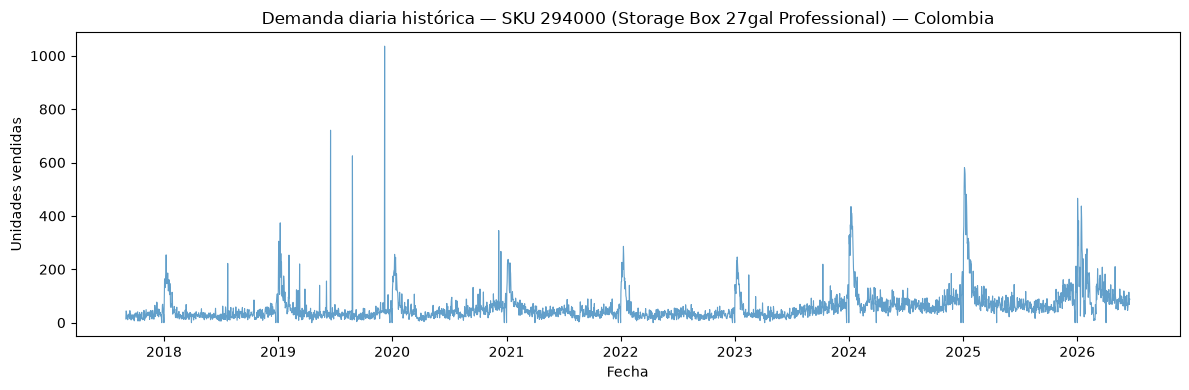

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    demanda_diaria["fecha"],
    demanda_diaria["demanda"],
    linewidth=0.8,
    alpha=0.7
)

ax.set_title(f"Demanda diaria histórica — SKU {SKU} ({NOMBRE_SKU}) — {PAIS}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Unidades vendidas")

plt.tight_layout()
plt.show()

### Crear Variables del modelo

In [18]:
df_model = demanda_diaria.copy()

# Variables de calendario
df_model["dia_semana"] = df_model["fecha"].dt.dayofweek
df_model["mes"] = df_model["fecha"].dt.month
df_model["semana_anio"] = df_model["fecha"].dt.isocalendar().week.astype(int)
df_model["es_finde"] = (df_model["dia_semana"] >= 5).astype(int)

# Lags
df_model["lag_7"] = df_model["demanda"].shift(7)
df_model["lag_14"] = df_model["demanda"].shift(14)
df_model["lag_30"] = df_model["demanda"].shift(30)

# Promedios móviles sin mirar el futuro
df_model["media_movil_7"] = df_model["demanda"].shift(1).rolling(7).mean()
df_model["media_movil_30"] = df_model["demanda"].shift(1).rolling(30).mean()

# Eliminar nulos creados por lags/promedios móviles
df_model = df_model.dropna().reset_index(drop=True)

print("Shape después de features:", df_model.shape)
print("\nFeatures creadas:")
print(df_model.columns.tolist())

display(df_model.head())

Shape después de features: (3183, 11)

Features creadas:
['fecha', 'demanda', 'dia_semana', 'mes', 'semana_anio', 'es_finde', 'lag_7', 'lag_14', 'lag_30', 'media_movil_7', 'media_movil_30']


,fecha,demanda,dia_semana,mes,semana_anio,es_finde,lag_7,lag_14,lag_30,media_movil_7,media_movil_30
0,2017-10-01,35.0,6,10,39,1,30.0,32.0,14.0,20.428571,23.700000
1,2017-10-02,27.0,0,10,40,0,12.0,10.0,44.0,21.142857,24.400000
2,2017-10-03,29.0,1,10,40,0,27.0,27.0,42.0,23.285714,23.833333
3,2017-10-04,37.0,2,10,40,0,17.0,15.0,15.0,23.571429,23.400000
4,2017-10-05,29.0,3,10,40,0,7.0,27.0,22.0,26.428571,24.133333


### Separar train/test

In [19]:
FEATURES = [
    "dia_semana",
    "mes",
    "semana_anio",
    "es_finde",
    "lag_7",
    "lag_14",
    "lag_30",
    "media_movil_7",
    "media_movil_30"
]

TARGET = "demanda"

X = df_model[FEATURES]
y = df_model[TARGET]

# División temporal: 80% train, 20% test
split_idx = int(len(df_model) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

fecha_corte = df_model["fecha"].iloc[split_idx]

print(f"Fecha de corte train/test: {fecha_corte.date()}")
print(f"Train: {len(X_train)} días ({df_model['fecha'].iloc[0].date()} a {df_model['fecha'].iloc[split_idx-1].date()})")
print(f"Test:  {len(X_test)} días ({fecha_corte.date()} a {df_model['fecha'].iloc[-1].date()})")

Fecha de corte train/test: 2024-09-20
Train: 2546 días (2017-10-01 a 2024-09-19)
Test:  637 días (2024-09-20 a 2026-06-18)


### Funciones de evaluación y MLflow

In [20]:
def evaluar_modelo(y_true, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    y_true_array = np.array(y_true)
    y_pred_array = np.array(y_pred)

    # Evitar división por cero en MAPE
    mask = y_true_array != 0

    if mask.sum() == 0:
        mape = np.nan
    else:
        mape = np.mean(
            np.abs((y_true_array[mask] - y_pred_array[mask]) / y_true_array[mask])
        ) * 100

    print(f"\n{nombre_modelo}")
    print(f"  MAE:  {mae:.2f} unidades")
    print(f"  RMSE: {rmse:.2f} unidades")
    print(f"  MAPE: {mape:.2f}%")

    return {
        "mae": mae,
        "rmse": rmse,
        "mape": mape
    }


def registrar_en_mlflow(run_name, params, metrics):
    """
    Registra parámetros y métricas en MLflow.
    No guarda el modelo aquí para evitar errores con XGBoost/sklearn.
    """
    try:
        with mlflow.start_run(run_name=run_name):
            for key, value in params.items():
                mlflow.log_param(key, value)

            for key, value in metrics.items():
                mlflow.log_metric(key, value)

        print(f"Corrida registrada en MLflow: {run_name}")

    except Exception as e:
        print(f"No se pudo registrar en MLflow la corrida {run_name}.")
        print("Error:", e)


tscv = TimeSeriesSplit(n_splits=5)

print("Configuración:")
print(f"SKU: {SKU}")
print(f"País: {PAIS}")
print(f"Features: {FEATURES}")
print("TimeSeriesSplit: 5 folds")
print(f"Train total: {len(X_train)} días")
print(f"Test total:  {len(X_test)} días")

Configuración:
SKU: 294000
País: Colombia
Features: ['dia_semana', 'mes', 'semana_anio', 'es_finde', 'lag_7', 'lag_14', 'lag_30', 'media_movil_7', 'media_movil_30']
TimeSeriesSplit: 5 folds
Train total: 2546 días
Test total:  637 días


### Modelo base: promedio móvil 7 días


Modelo Base (Promedio Móvil 7 días)
  MAE:  30.77 unidades
  RMSE: 51.95 unidades
  MAPE: 34.47%


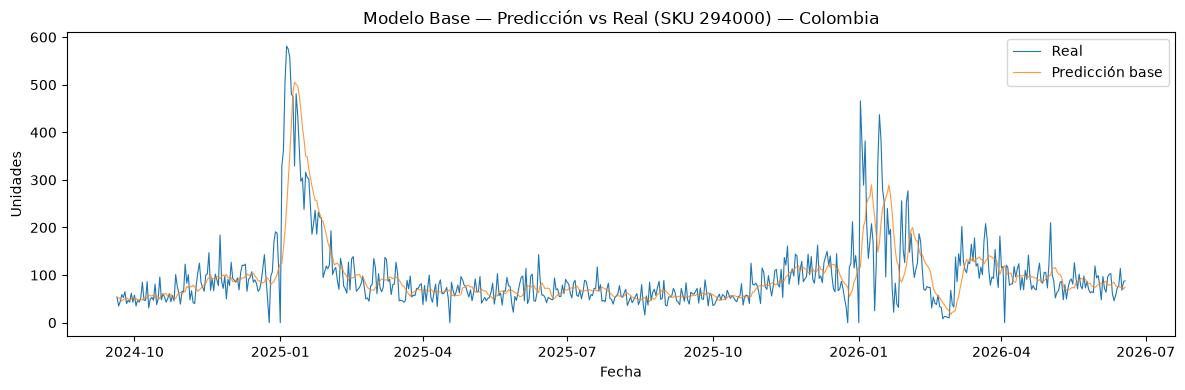

In [21]:
y_pred_base = X_test["media_movil_7"]

metricas_base = evaluar_modelo(
    y_test,
    y_pred_base,
    "Modelo Base (Promedio Móvil 7 días)"
)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    df_model["fecha"].iloc[split_idx:],
    y_test.values,
    label="Real",
    linewidth=0.8
)

ax.plot(
    df_model["fecha"].iloc[split_idx:],
    y_pred_base.values,
    label="Predicción base",
    linewidth=0.8,
    alpha=0.8
)

ax.set_title(f"Modelo Base — Predicción vs Real (SKU {SKU}) — {PAIS}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Unidades")
ax.legend()

plt.tight_layout()
plt.show()

#### Guardar en MLflow

In [22]:
registrar_en_mlflow(
    run_name=f"{SKU}_{PAIS}_baseline_media_movil_7",
    params={
        "sku": SKU,
        "pais": PAIS,
        "nombre_sku": NOMBRE_SKU,
        "modelo": "Baseline media móvil 7 días",
        "features": "media_movil_7"
    },
    metrics={
        "MAE": metricas_base["mae"],
        "RMSE": metricas_base["rmse"],
        "MAPE": metricas_base["mape"]
    }
)

🏃 View run 294000_Colombia_baseline_media_movil_7 at: http://44.200.196.170:5000/#/experiments/465688225033163177/runs/11170387d10d4e25a29801cb4f2ab4a5
🧪 View experiment at: http://44.200.196.170:5000/#/experiments/465688225033163177
Corrida registrada en MLflow: 294000_Colombia_baseline_media_movil_7


### RANDOM FOREST

In [23]:
mae_cv_rf = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_cv_train = X_train.iloc[train_idx]
    X_cv_val = X_train.iloc[val_idx]

    y_cv_train = y_train.iloc[train_idx]
    y_cv_val = y_train.iloc[val_idx]

    rf = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_cv_train, y_cv_train)
    y_cv_pred = rf.predict(X_cv_val)

    mae_fold = mean_absolute_error(y_cv_val, y_cv_pred)
    mae_cv_rf.append(mae_fold)

    print(f"Fold {fold + 1} MAE: {mae_fold:.2f}")

print(f"\nMAE promedio CV Random Forest: {np.mean(mae_cv_rf):.2f} (+/- {np.std(mae_cv_rf):.2f})")

rf_final = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

y_pred_rf = rf_final.predict(X_test)

metricas_rf = evaluar_modelo(
    y_test,
    y_pred_rf,
    "Random Forest"
)

Fold 1 MAE: 23.36
Fold 2 MAE: 21.71
Fold 3 MAE: 15.38
Fold 4 MAE: 14.48
Fold 5 MAE: 26.88

MAE promedio CV Random Forest: 20.36 (+/- 4.75)

Random Forest
  MAE:  33.11 unidades
  RMSE: 54.19 unidades
  MAPE: 33.05%


#### Registrar Random Forest en MLflow

In [24]:
registrar_en_mlflow(
    run_name=f"{SKU}_{PAIS}_random_forest",
    params={
        "sku": SKU,
        "pais": PAIS,
        "nombre_sku": NOMBRE_SKU,
        "modelo": "RandomForestRegressor",
        "n_estimators": 100,
        "features": ",".join(FEATURES)
    },
    metrics={
        "MAE": metricas_rf["mae"],
        "RMSE": metricas_rf["rmse"],
        "MAPE": metricas_rf["mape"],
        "MAE_CV_PROMEDIO": np.mean(mae_cv_rf)
    }
)

🏃 View run 294000_Colombia_random_forest at: http://44.200.196.170:5000/#/experiments/465688225033163177/runs/6785e141fb0c43f0a66623b57c294792
🧪 View experiment at: http://44.200.196.170:5000/#/experiments/465688225033163177
Corrida registrada en MLflow: 294000_Colombia_random_forest


### Modelo XGBoost con TimeSeriesSplit

In [25]:
if xgboost_disponible:

    mae_cv_xgb = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_cv_train = X_train.iloc[train_idx]
        X_cv_val = X_train.iloc[val_idx]

        y_cv_train = y_train.iloc[train_idx]
        y_cv_val = y_train.iloc[val_idx]

        xgb = XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42,
            verbosity=0
        )

        xgb.fit(X_cv_train, y_cv_train)
        y_cv_pred = xgb.predict(X_cv_val)

        mae_fold = mean_absolute_error(y_cv_val, y_cv_pred)
        mae_cv_xgb.append(mae_fold)

        print(f"Fold {fold + 1} MAE: {mae_fold:.2f}")

    print(f"\nMAE promedio CV XGBoost: {np.mean(mae_cv_xgb):.2f} (+/- {np.std(mae_cv_xgb):.2f})")

    xgb_final = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )

    xgb_final.fit(X_train, y_train)

    y_pred_xgb = xgb_final.predict(X_test)

    metricas_xgb = evaluar_modelo(
        y_test,
        y_pred_xgb,
        "XGBoost"
    )

else:
    print("No se corrió XGBoost porque no está instalado.")
    mae_cv_xgb = []
    xgb_final = None
    y_pred_xgb = None
    metricas_xgb = None

Fold 1 MAE: 24.18
Fold 2 MAE: 21.28
Fold 3 MAE: 15.37
Fold 4 MAE: 14.07
Fold 5 MAE: 28.07

MAE promedio CV XGBoost: 20.59 (+/- 5.27)

XGBoost
  MAE:  34.17 unidades
  RMSE: 55.21 unidades
  MAPE: 34.23%


### Registrar XGBoost en MLflow

In [26]:
if xgboost_disponible:

    registrar_en_mlflow(
        run_name=f"{SKU}_{PAIS}_xgboost",
        params={
            "sku": SKU,
            "pais": PAIS,
            "nombre_sku": NOMBRE_SKU,
            "modelo": "XGBRegressor",
            "n_estimators": 100,
            "learning_rate": 0.1,
            "features": ",".join(FEATURES)
        },
        metrics={
            "MAE": metricas_xgb["mae"],
            "RMSE": metricas_xgb["rmse"],
            "MAPE": metricas_xgb["mape"],
            "MAE_CV_PROMEDIO": np.mean(mae_cv_xgb)
        }
    )

🏃 View run 294000_Colombia_xgboost at: http://44.200.196.170:5000/#/experiments/465688225033163177/runs/060897ddff1f43cab70c88952124148c
🧪 View experiment at: http://44.200.196.170:5000/#/experiments/465688225033163177
Corrida registrada en MLflow: 294000_Colombia_xgboost


### Comparar resultados

In [27]:
resultados_modelos = [
    {
        "modelo": "Base promedio móvil 7 días",
        "MAE": metricas_base["mae"],
        "RMSE": metricas_base["rmse"],
        "MAPE": metricas_base["mape"]
    },
    {
        "modelo": "Random Forest",
        "MAE": metricas_rf["mae"],
        "RMSE": metricas_rf["rmse"],
        "MAPE": metricas_rf["mape"]
    }
]

if xgboost_disponible:
    resultados_modelos.append({
        "modelo": "XGBoost",
        "MAE": metricas_xgb["mae"],
        "RMSE": metricas_xgb["rmse"],
        "MAPE": metricas_xgb["mape"]
    })

resultados = pd.DataFrame(resultados_modelos)
resultados = resultados.sort_values("MAPE").reset_index(drop=True)

display(resultados)

,modelo,MAE,RMSE,MAPE
0,Random Forest,33.109137,54.191498,33.046694
1,XGBoost,34.174725,55.206738,34.225407
2,Base promedio móvil 7 días,30.766540,51.950572,34.472949


### Compracion Visual de modelos

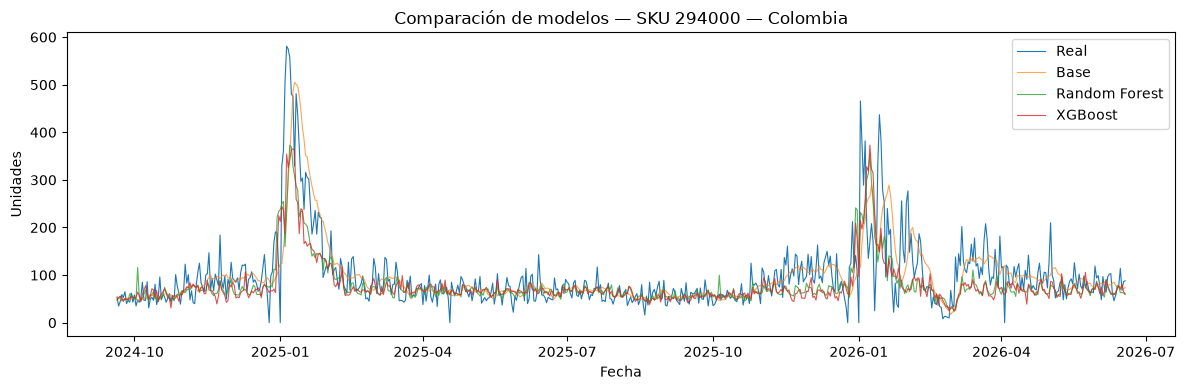

In [28]:
fig, ax = plt.subplots(figsize=(12, 4))

fechas_test = df_model["fecha"].iloc[split_idx:]

ax.plot(
    fechas_test,
    y_test.values,
    label="Real",
    linewidth=0.8
)

ax.plot(
    fechas_test,
    y_pred_base.values,
    label="Base",
    linewidth=0.8,
    alpha=0.7
)

ax.plot(
    fechas_test,
    y_pred_rf,
    label="Random Forest",
    linewidth=0.8,
    alpha=0.8
)

if xgboost_disponible:
    ax.plot(
        fechas_test,
        y_pred_xgb,
        label="XGBoost",
        linewidth=0.8,
        alpha=0.8
    )

ax.set_title(f"Comparación de modelos — SKU {SKU} — {PAIS}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Unidades")
ax.legend()

plt.tight_layout()
plt.show()

### Guardar mejor resultado

In [41]:
# Seleccionar y guardar solo el mejor modelo con joblib

mejor_modelo_nombre = resultados.iloc[0]["modelo"]

if mejor_modelo_nombre == "Random Forest":
    mejor_modelo = rf_final
    y_pred_mejor = y_pred_rf

elif mejor_modelo_nombre == "XGBoost":
    mejor_modelo = xgb_final
    y_pred_mejor = y_pred_xgb

else:
    mejor_modelo = None
    y_pred_mejor = y_pred_base

print("Mejor modelo:", mejor_modelo_nombre)
print(f"MAPE: {resultados.iloc[0]['MAPE']:.2f}%")
print(f"MAE:  {resultados.iloc[0]['MAE']:.2f} unidades")
print(f"RMSE: {resultados.iloc[0]['RMSE']:.2f} unidades")

if mejor_modelo is not None:
    modelo_final_path = f"../models/modelo_{SKU}_{PAIS}.pkl"
    joblib.dump(mejor_modelo, modelo_final_path)
    print(f"Modelo guardado en: {modelo_final_path}")
else:
    modelo_final_path = None
    print("El mejor modelo fue el baseline, por eso no se guarda modelo sklearn.")

Mejor modelo: Random Forest
MAPE: 33.05%
MAE:  33.11 unidades
RMSE: 54.19 unidades
Modelo guardado en: ../models/modelo_294000_Colombia.pkl


### Registrar el mejor modelo final en MLflow como artifact

In [42]:
if modelo_final_path is not None:

    try:
        with mlflow.start_run(run_name=f"{SKU}_{PAIS}_mejor_modelo_final"):
            mlflow.log_param("sku", SKU)
            mlflow.log_param("pais", PAIS)
            mlflow.log_param("nombre_sku", NOMBRE_SKU)
            mlflow.log_param("modelo_seleccionado", mejor_modelo_nombre)
            
            mlflow.log_metric("MAE", resultados.iloc[0]["MAE"])
            mlflow.log_metric("RMSE", resultados.iloc[0]["RMSE"])
            mlflow.log_metric("MAPE", resultados.iloc[0]["MAPE"])
            
            # Subir el modelo guardado con joblib como artifact genérico
            mlflow.log_artifact(modelo_final_path, artifact_path="modelo_final")

        print("Mejor modelo registrado en MLflow como artifact.")

    except Exception as e:
        print("No se pudo subir el mejor modelo como artifact en MLflow.")
        print("Error:", e)
else:
    print("No hay modelo final para subir como artifact porque ganó el baseline.")

Mejor modelo registrado en MLflow como artifact.


### Guardar tabla de resultados

In [43]:
resultados.to_csv(f"../models/resultados_modelo_{SKU}_{PAIS}.csv", index=False)

print(f"Resultados guardados en: ../models/resultados_modelo_{SKU}_{PAIS}.csv")

Resultados guardados en: ../models/resultados_modelo_294000_Colombia.csv


### Importancia de variables del mejor modelo

,variable,importancia
2,semana_anio,0.382657
7,media_movil_7,0.201553
8,media_movil_30,0.117879
6,lag_30,0.076135
5,lag_14,0.070105
4,lag_7,0.061614
0,dia_semana,0.048558
3,es_finde,0.028359
1,mes,0.013138


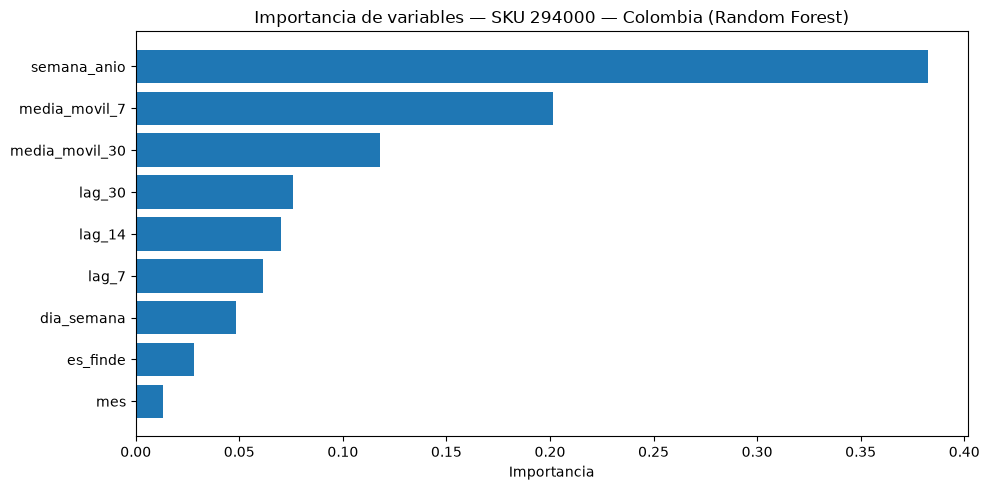

In [44]:
if mejor_modelo is not None and hasattr(mejor_modelo, "feature_importances_"):

    importancias = pd.DataFrame({
        "variable": FEATURES,
        "importancia": mejor_modelo.feature_importances_
    }).sort_values("importancia", ascending=False)

    display(importancias)

    fig, ax = plt.subplots(figsize=(10, 5))

    importancias_ordenadas = importancias.sort_values("importancia", ascending=True)

    ax.barh(
        importancias_ordenadas["variable"],
        importancias_ordenadas["importancia"]
    )

    ax.set_title(f"Importancia de variables — SKU {SKU} — {PAIS} ({mejor_modelo_nombre})")
    ax.set_xlabel("Importancia")

    plt.tight_layout()
    plt.show()

else:
    print("El mejor modelo no tiene importancia de variables disponible.")

### Forecast generado

In [45]:
def generar_forecast(horizonte):
    ultima_fecha = demanda_diaria["fecha"].max()

    fechas_futuras = pd.date_range(
        start=ultima_fecha + pd.Timedelta(days=1),
        periods=horizonte
    )

    predicciones = []
    historial = demanda_diaria["demanda"].values.tolist()

    for fecha in fechas_futuras:

        features_pred = {
            "dia_semana": fecha.dayofweek,
            "mes": fecha.month,
            "semana_anio": fecha.isocalendar()[1],
            "es_finde": int(fecha.dayofweek >= 5),
            "lag_7": historial[-7],
            "lag_14": historial[-14],
            "lag_30": historial[-30],
            "media_movil_7": np.mean(historial[-7:]),
            "media_movil_30": np.mean(historial[-30:])
        }

        X_pred = pd.DataFrame([features_pred])

        if mejor_modelo is None:
            pred = X_pred["media_movil_7"].iloc[0]
        else:
            pred = mejor_modelo.predict(X_pred)[0]

        pred = max(0, pred)

        predicciones.append(pred)
        historial.append(pred)

    forecast = pd.DataFrame({
        "fecha": fechas_futuras,
        "sku": SKU,
        "pais": PAIS,
        "horizonte_dias": horizonte,
        "demanda_forecast": [round(p) for p in predicciones]
    })

    return forecast

In [46]:
forecast_30d = generar_forecast(30)
forecast_60d = generar_forecast(60)
forecast_90d = generar_forecast(90)

forecast_df = pd.concat(
    [forecast_30d, forecast_60d, forecast_90d],
    ignore_index=True
)

display(forecast_df.head())
display(forecast_df.tail())

print("Forecast total 30 días:", forecast_30d["demanda_forecast"].sum())
print("Forecast total 60 días:", forecast_60d["demanda_forecast"].sum())
print("Forecast total 90 días:", forecast_90d["demanda_forecast"].sum())

print("\nPromedio diario 30 días:", round(forecast_30d["demanda_forecast"].mean(), 2))
print("Promedio diario 60 días:", round(forecast_60d["demanda_forecast"].mean(), 2))
print("Promedio diario 90 días:", round(forecast_90d["demanda_forecast"].mean(), 2))

,fecha,sku,pais,horizonte_dias,demanda_forecast
0,2026-06-19,294000,Colombia,30,57
1,2026-06-20,294000,Colombia,30,70
2,2026-06-21,294000,Colombia,30,94
3,2026-06-22,294000,Colombia,30,79
4,2026-06-23,294000,Colombia,30,62


,fecha,sku,pais,horizonte_dias,demanda_forecast
175,2026-09-12,294000,Colombia,90,76
176,2026-09-13,294000,Colombia,90,77
177,2026-09-14,294000,Colombia,90,65
178,2026-09-15,294000,Colombia,90,60
179,2026-09-16,294000,Colombia,90,60


Forecast total 30 días: 2002
Forecast total 60 días: 3957
Forecast total 90 días: 5888

Promedio diario 30 días: 66.73
Promedio diario 60 días: 65.95
Promedio diario 90 días: 65.42


### Guardar forecast

In [47]:
forecast_30d.to_csv(f"../models/forecast_30d_{SKU}_{PAIS}.csv", index=False)
forecast_60d.to_csv(f"../models/forecast_60d_{SKU}_{PAIS}.csv", index=False)
forecast_90d.to_csv(f"../models/forecast_90d_{SKU}_{PAIS}.csv", index=False)

forecast_df.to_csv(f"../models/forecast_30_60_90d_{SKU}_{PAIS}.csv", index=False)

print(f"Forecast 30 días guardado en: ../models/forecast_30d_{SKU}_{PAIS}.csv")
print(f"Forecast 60 días guardado en: ../models/forecast_60d_{SKU}_{PAIS}.csv")
print(f"Forecast 90 días guardado en: ../models/forecast_90d_{SKU}_{PAIS}.csv")
print(f"Forecast consolidado guardado en: ../models/forecast_30_60_90d_{SKU}_{PAIS}.csv")

Forecast 30 días guardado en: ../models/forecast_30d_294000_Colombia.csv
Forecast 60 días guardado en: ../models/forecast_60d_294000_Colombia.csv
Forecast 90 días guardado en: ../models/forecast_90d_294000_Colombia.csv
Forecast consolidado guardado en: ../models/forecast_30_60_90d_294000_Colombia.csv


### Gráfico histórico reciente + forecast

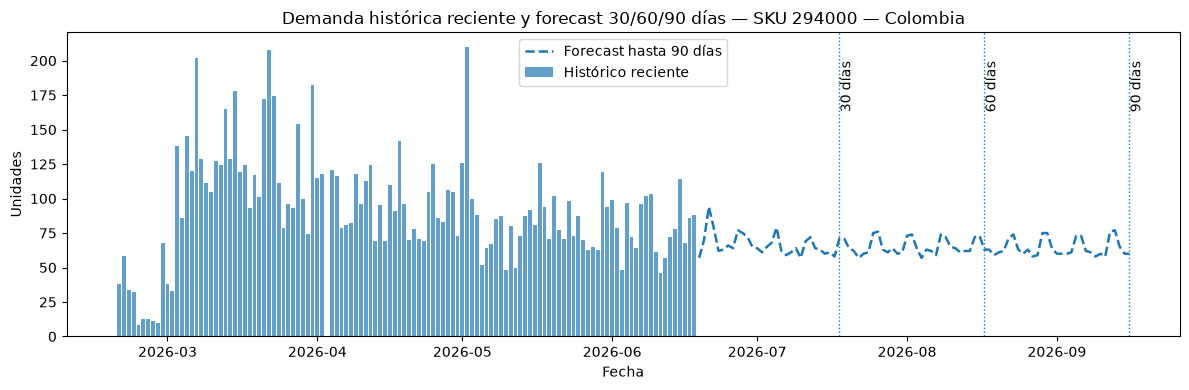

In [50]:
fig, ax = plt.subplots(figsize=(12, 4))

hist_plot = demanda_diaria.tail(120)

# Histórico reciente
ax.bar(
    hist_plot["fecha"],
    hist_plot["demanda"],
    label="Histórico reciente",
    alpha=0.7
)

# Forecast completo a 90 días
ax.plot(
    forecast_90d["fecha"],
    forecast_90d["demanda_forecast"],
    linestyle="--",
    linewidth=1.8,
    label="Forecast hasta 90 días"
)

# Líneas verticales para marcar horizontes
fecha_30 = forecast_90d["fecha"].iloc[29]
fecha_60 = forecast_90d["fecha"].iloc[59]
fecha_90 = forecast_90d["fecha"].iloc[89]

ax.axvline(fecha_30, linestyle=":", linewidth=1)
ax.axvline(fecha_60, linestyle=":", linewidth=1)
ax.axvline(fecha_90, linestyle=":", linewidth=1)

# Textos de horizonte
y_max = max(hist_plot["demanda"].max(), forecast_90d["demanda_forecast"].max())

ax.text(fecha_30, y_max * 0.95, "30 días", rotation=90, va="top")
ax.text(fecha_60, y_max * 0.95, "60 días", rotation=90, va="top")
ax.text(fecha_90, y_max * 0.95, "90 días", rotation=90, va="top")

ax.set_title(f"Demanda histórica reciente y forecast 30/60/90 días — SKU {SKU} — {PAIS}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Unidades")
ax.legend()

plt.tight_layout()
plt.show()

### Resumen final para reporte

In [51]:
resumen_forecast = pd.DataFrame({
    "horizonte": ["30 días", "60 días", "90 días"],
    "demanda_total_forecast": [
        forecast_30d["demanda_forecast"].sum(),
        forecast_60d["demanda_forecast"].sum(),
        forecast_90d["demanda_forecast"].sum()
    ],
    "demanda_promedio_diaria": [
        forecast_30d["demanda_forecast"].mean(),
        forecast_60d["demanda_forecast"].mean(),
        forecast_90d["demanda_forecast"].mean()
    ]
})

display(resumen_forecast)

,horizonte,demanda_total_forecast,demanda_promedio_diaria
0,30 días,2002,66.733333
1,60 días,3957,65.950000
2,90 días,5888,65.422222
